# Testing the 'drift' optimization of the degree-of-freedom parameter for t-SNE embedding and comparison to the 'gradient descent' method

This notebook demonstrates a method for optimizing the degree-of-freedom (alpha) parameter during a t-SNE embedding process. The purpose of this optimization is to refine the embedding by minimizing the Kullback-Leibler (KL) divergence, which measures the difference between the original and embedded distributions.

**Purpose:** The optimization focuses on iteratively adjusting the alpha parameter to improve the embedding's quality, particularly when optimizing for "drift."

**Rationale:** By testing incremental changes to the alpha value and evaluating the resulting KL divergence, the algorithm ensures that the parameter adjustments move toward lower divergence values, thereby enhancing the embedding.

**Implementation Details:**

* The process starts with an initial alpha value and tests small adjustments using a learning rate (alpha_lr).
* If the KL divergence improves (decreases) after a temporary optimization step, the alpha parameter is updated in the same direction by adding the learning rate.
* If the KL divergence worsens (increases), the alpha parameter is adjusted in the opposite direction by subtracting the learning rate.
* The embedding is then updated with the final alpha value for the iteration.


This approach allows for dynamic fine-tuning of the degree-of-freedom parameter, ensuring that the embedding remains faithful to the data distribution while maintaining computational efficiency.

In [1]:
from sklearn.datasets import make_swiss_roll
from sklearn.datasets import load_digits
import seaborn as sns
from python_tsne_utils import utils
import importlib
importlib.reload(utils)
import matplotlib.pyplot as plt 

In [2]:
X, color = make_swiss_roll(n_samples=500, noise=0.0, random_state=42)

In [3]:
test_alpha = float(1)

In [4]:
tsne_result_1_opt_drift = utils.tsne_with_dof_optimisation(X=X, n_iter = 500, initial_alpha=test_alpha, alpha_lr=0.1,dataset_name='SwissRoll', optimise_for_alpha='drift', verbose=True)

Initializing the t-SNE embedding...
Computing the affinity matrix...
Performing the PCA initialization...
Initializing the t-SNE embedding...
Performing the early exaggeration fase with exaggeration = 12 and learning rate = 41.666666666666664 for 250 iterations...
Running optimization for 500 iterations...
Iteration 0 out of 500 done
Current KL divergence: 2.3428644119750803
Current alpha: 1.0
Current alpha gradient: 0.0
-----------------------------------
Iteration 1 out of 500 done
Current KL divergence: 1.9566288635087012
Current alpha: 1.01
Current alpha gradient: 0.0
-----------------------------------
Iteration 2 out of 500 done
Current KL divergence: 1.5414358790471105
Current alpha: 1.02
Current alpha gradient: 0.0
-----------------------------------
Iteration 3 out of 500 done
Current KL divergence: 1.2418887581860663
Current alpha: 1.03
Current alpha gradient: 0.0
-----------------------------------
Iteration 4 out of 500 done
Current KL divergence: 1.0397090727788179
Current

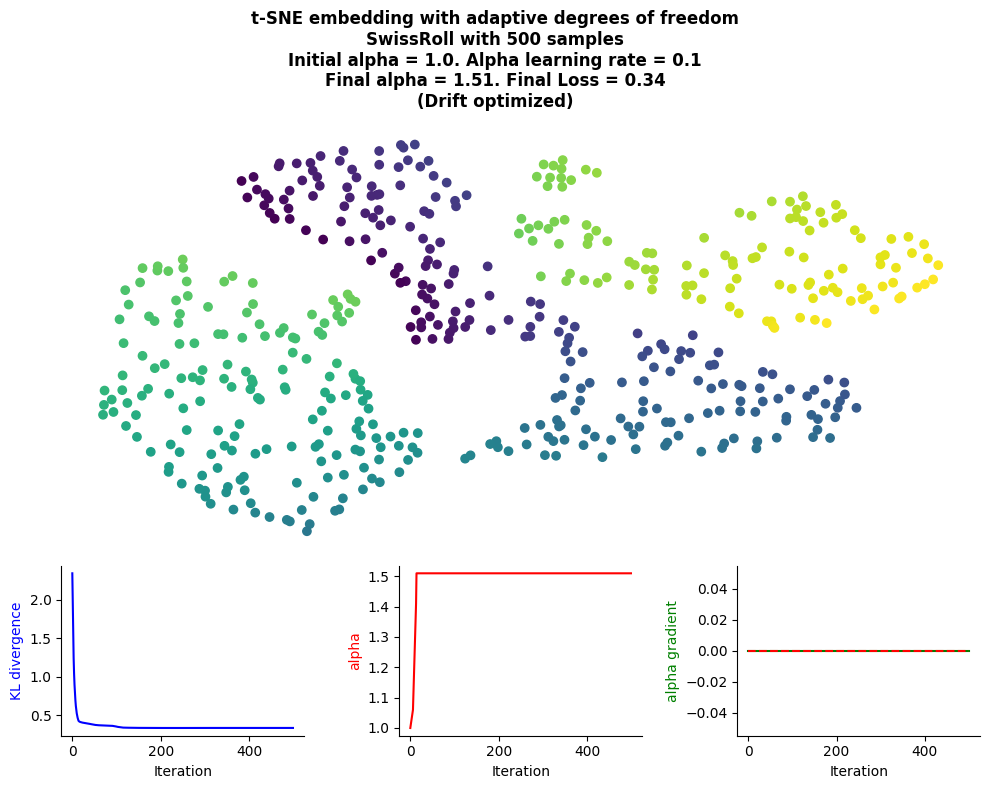

In [5]:
utils.plot_tsne_result(tsne_result_1_opt_drift, color, additional_title='(Drift optimized)')

In [6]:
tsne_result_1_gd = utils.tsne_with_dof_optimisation(X=X, n_iter = 500, initial_alpha=test_alpha, alpha_lr=0.5,dataset_name='SwissRoll', optimise_for_alpha='exact', verbose=True)

Initializing the t-SNE embedding...
Computing the affinity matrix...
Performing the PCA initialization...
Initializing the t-SNE embedding...
Performing the early exaggeration fase with exaggeration = 12 and learning rate = 41.666666666666664 for 250 iterations...
Running optimization for 500 iterations...
Computing the exact gradients...
Iteration 0 out of 500 done
Current KL divergence: 1.9403002028726597
Current alpha: 1.0530275214700062
Current alpha gradient: -0.10605504294001224
-----------------------------------
Iteration 1 out of 500 done
Current KL divergence: 1.4601985654595424
Current alpha: 1.183195868611598
Current alpha gradient: -0.2603366942831835
-----------------------------------
Iteration 2 out of 500 done
Current KL divergence: 1.074001729217505
Current alpha: 1.363997478042971
Current alpha gradient: -0.3616032188627459
-----------------------------------
Iteration 3 out of 500 done
Current KL divergence: 0.8149053629073073
Current alpha: 1.5291230094072732
Curre

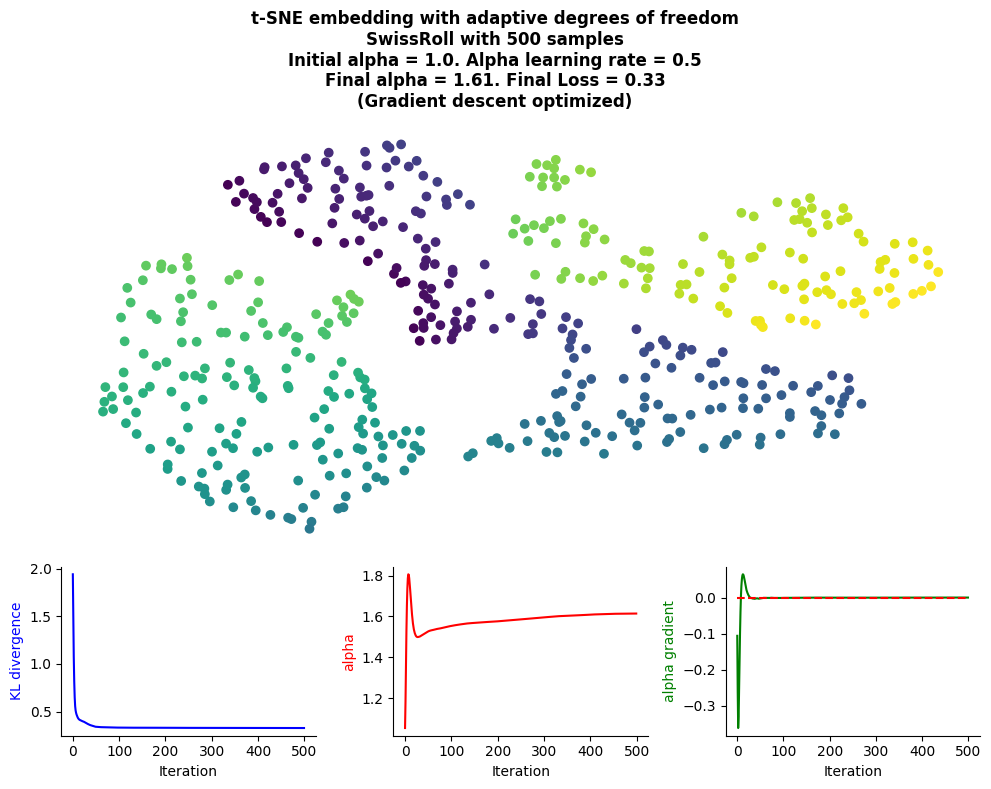

In [7]:
utils.plot_tsne_result(tsne_result_1_gd, color, additional_title='(Gradient descent optimized)')   

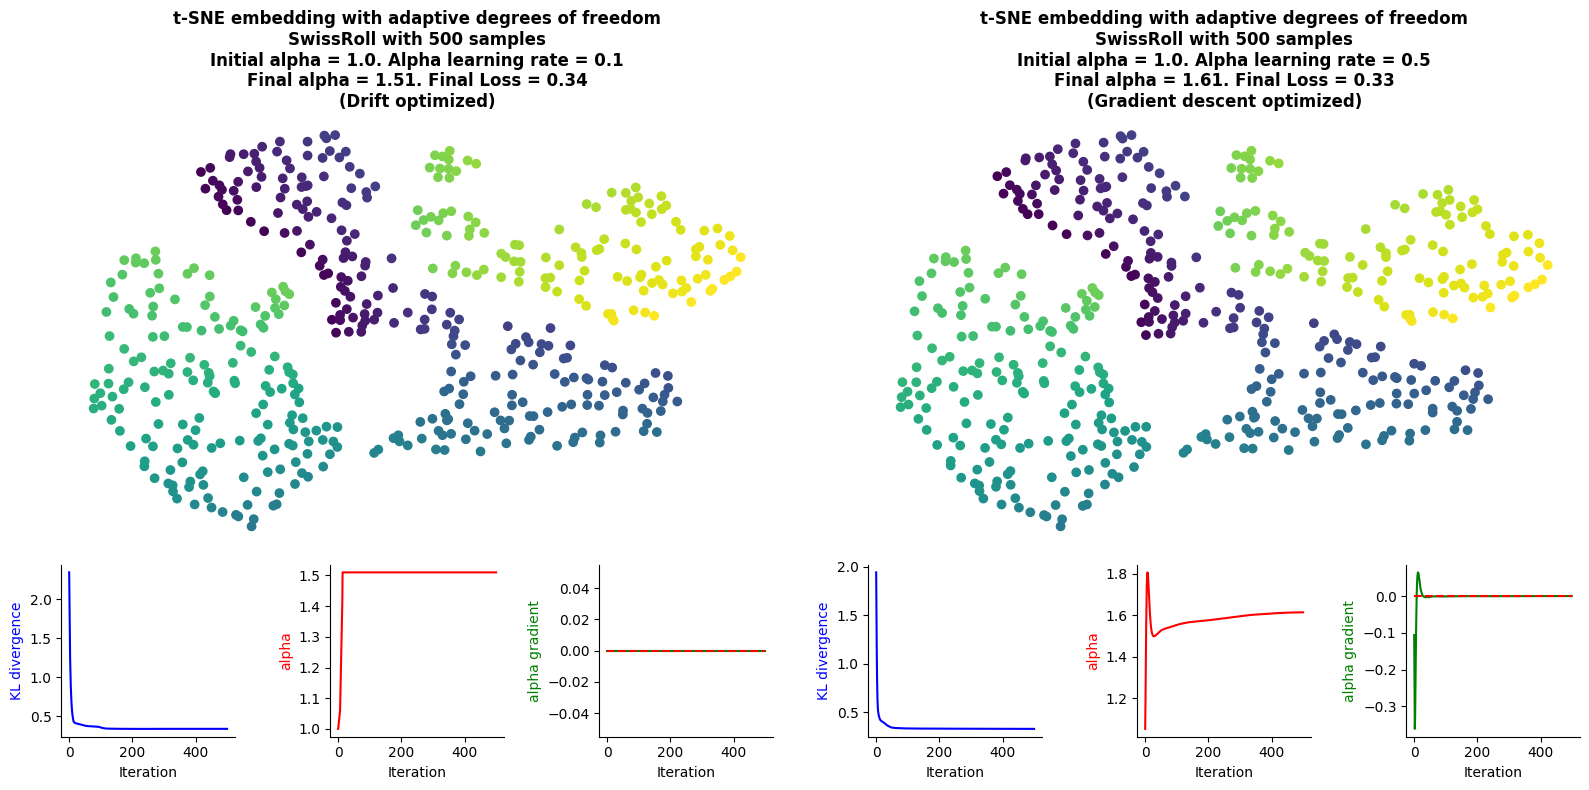

In [8]:
utils.plot_side_by_side(tsne_result_1_opt_drift, tsne_result_1_gd, color, additional_title_1='(Drift optimized)', additional_title_2='(Gradient descent optimized)')

In [9]:
test_alpha = float(5)

Initializing the t-SNE embedding...
Computing the affinity matrix...
Performing the PCA initialization...
Initializing the t-SNE embedding...
Performing the early exaggeration fase with exaggeration = 12 and learning rate = 41.666666666666664 for 250 iterations...
Running optimization for 500 iterations...
Computing the exact gradients...
Iteration 0 out of 500 done
Current KL divergence: 1.438899673027084
Current alpha: 5.005956805176385
Current alpha gradient: -0.011913610352770913
-----------------------------------
Iteration 1 out of 500 done
Current KL divergence: 0.9906824977968807
Current alpha: 5.016023849756644
Current alpha gradient: -0.02013408916051689
-----------------------------------
Iteration 2 out of 500 done
Current KL divergence: 0.787062602598736
Current alpha: 5.022992480029224
Current alpha gradient: -0.013937260545158432
-----------------------------------
Iteration 3 out of 500 done
Current KL divergence: 0.7243838460406522
Current alpha: 5.020486182602211
Curr

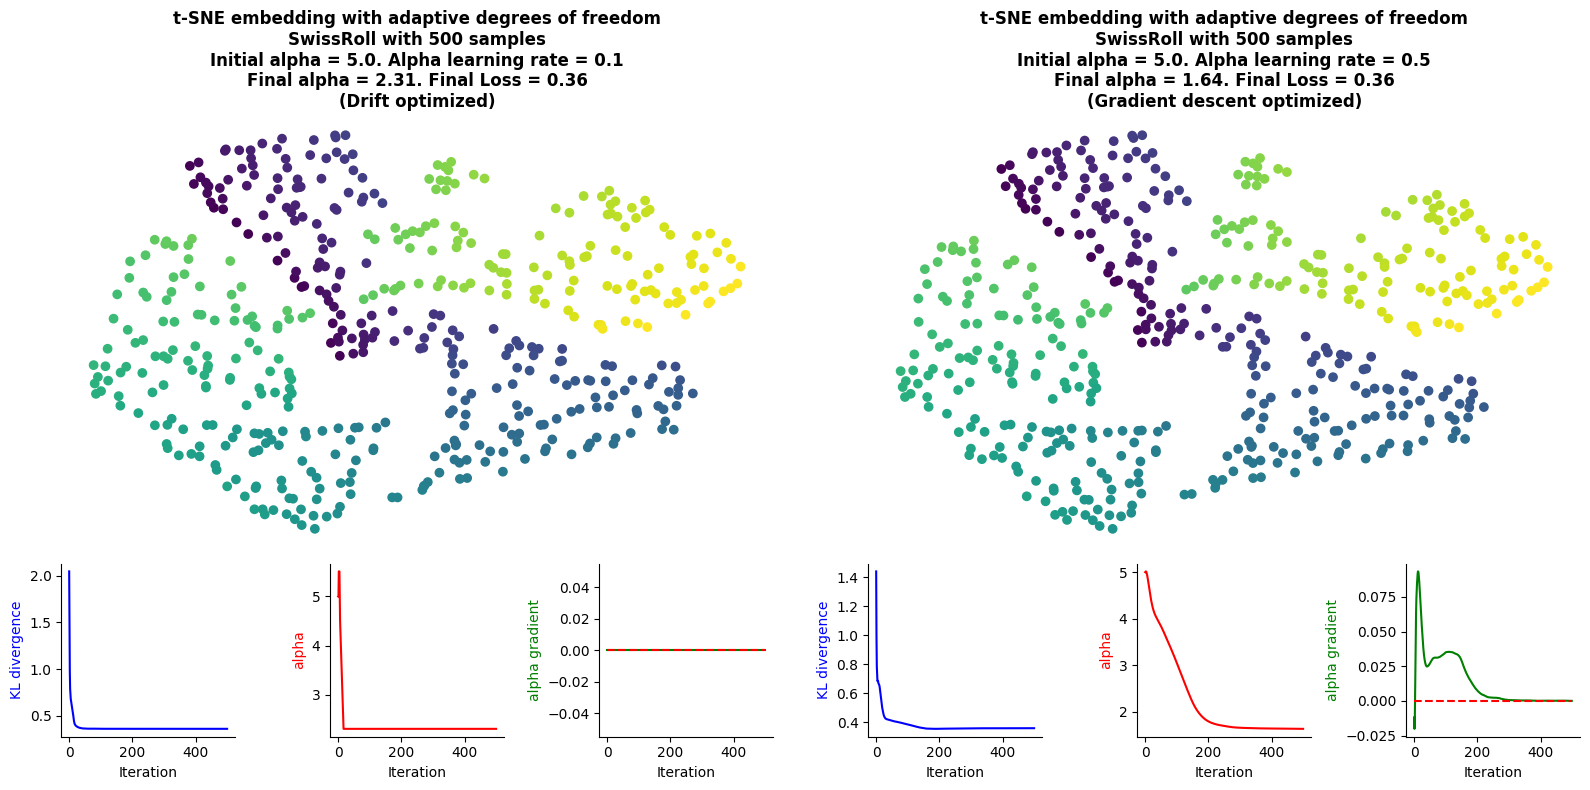

In [10]:
tsne_result_5_gd = utils.tsne_with_dof_optimisation(X=X, n_iter = 500, initial_alpha=test_alpha, alpha_lr=0.5,dataset_name='SwissRoll', optimise_for_alpha='exact', verbose=True)
tsne_result_5_opt_drift = utils.tsne_with_dof_optimisation(X=X, n_iter = 500, initial_alpha=test_alpha, alpha_lr=0.1,dataset_name='SwissRoll', optimise_for_alpha='drift', verbose=True)
utils.plot_side_by_side(tsne_result_5_opt_drift, tsne_result_5_gd, color, additional_title_1='(Drift optimized)', additional_title_2='(Gradient descent optimized)')